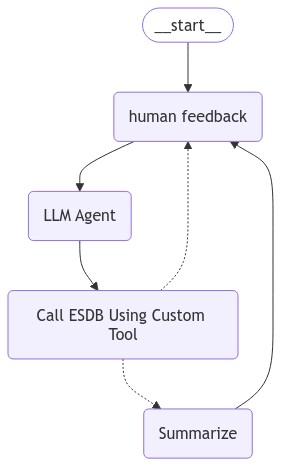

LLM is processing the request...
LLM needs to call a tool...
Calling a ESDB for denied loans.
tool input: DeniedLoans
RecordedEvent(type='$>', data=b'2@loanRequest-35007256-0e40-8f23-d14b-9fbb41d372fd', metadata=b'{"$v":"6:-1:0:4","$s":{"$ce-loanRequest":7},"$correlationId":"35007256-0e40-8f23-d14b-9fbb41d372fd","$causationId":"c4443854-d6da-4037-b610-2675dc2816c5","transactionTimestamp":"2024-11-05 12:19:40.825599","$causedBy":"43754e34-a56b-44e6-a8c3-bf970078d620"}', content_type='application/octet-stream', id=UUID('dd90881f-2a73-44f5-916f-a3149f519294'), stream_name='DeniedLoans', stream_position=0, commit_position=36584, prepare_position=36584, recorded_at=datetime.datetime(2024, 11, 5, 17, 19, 40, 836878, tzinfo=datetime.timezone.utc), link=None, retry_count=None)
RecordedEvent(type='$>', data=b'2@loanRequest-68a5f087-2063-d4bb-c29d-4a3c9f59d439', metadata=b'{"$v":"6:-1:0:4","$s":{"$ce-loanRequest":18},"$correlationId":"68a5f087-2063-d4bb-c29d-4a3c9f59d439","$causationId":"af6527e


KeyboardInterrupt



In [8]:
from langchain.globals import set_debug
# set_debug(True)

from langgraph.checkpoint.memory import MemorySaver
from esdbclient import EventStoreDBClient
from langchain_community.tools.eventstoredb.tool import EventStoreDBTool
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

from langgraph.graph import StateGraph, START, END, MessagesState
from typing import Annotated, Literal
from typing_extensions import TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
import uuid
import pandas as pd
from IPython.display import Image, display

# Establish connection to ESDB and reuse this connection in the ESDB tool
esdb_client = EventStoreDBClient(
    uri="esdb://localhost:2113?Tls=false"
)

def describe_loans_from_dataframe(structured_response):
    data = []
    for event in structured_response:
        data.append({
            "type": event.type,
            "data": event.data.decode() if isinstance(event.data, bytes) else event.data,
            "metadata": event.metadata.decode() if isinstance(event.metadata, bytes) else event.metadata,
            "content_type": event.content_type,
            "id": str(event.id),
            "stream_name": event.stream_name,
            "stream_position": event.stream_position,
            "commit_position": event.commit_position,
            "prepare_position": event.prepare_position,
            "recorded_at": event.recorded_at,
            "link": event.link,
            "retry_count": event.retry_count
        })

    df = pd.DataFrame(data)
    print(df)
    import matplotlib.pyplot as plt

    # Count occurrences of each unique value in the 'type' column
    type_counts = df['type'].value_counts()

    # Plot pie chart
    type_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, figsize=(6, 6))
    plt.title("Distribution of 'type' Field")
    plt.ylabel('')  # Hide the y-label for a cleaner look
    plt.show()

    # Count occurrences of each unique value in the 'type' column
    type_percentages = type_counts / type_counts.sum() * 100

    # Generate a summary text
    summary_text = "Summary of 'type' field distribution:\n"
    for type_name, count in type_counts.items():
        percentage = type_percentages[type_name]
        summary_text += f"- {type_name}: {count} items ({percentage:.1f}%)\n"
    # print(summary_text)
    return "We found "+ str(len(df))+ "denied loans. "+summary_text

@tool
def call_eventstore_on_loans(query: str):
    """Call to find loan status details"""
    print("Requesting loan with id: ", query)
    try:
        # Attempt to create a UUID object from the string
        _uuid = uuid.UUID(query.removeprefix("loanRequest-"))
        response = EventStoreDBTool(esdb_client=esdb_client, structured=False).invoke(query)
        # print("response from ESDB: ", response)
        return response
    except ValueError:
        # If it raises a ValueError, it's not a valid GUID
        return "Could not find Loan with id: "+query

@tool
def call_eventstore_to_get_approved_loans(query: str):
    """
    Called to get a list of all approved loans and a summary of those approved loans.
    """
    print("Calling a ESDB for approved loans.")
    structured_response = EventStoreDBTool(esdb_client=esdb_client, structured=True).invoke(query)
    return describe_loans_from_dataframe(structured_response)


@tool
def call_eventstore_to_get_denied_loans(query: str):
    """
    Called to get a list of all denied loans and a summary of those approved loans.
    """
    print("Calling a ESDB for denied loans.")
    structured_response = EventStoreDBTool(esdb_client=esdb_client, structured=True).invoke(query)
    return describe_loans_from_dataframe(structured_response)


def loan_request(state):
    print("load request simple node")
    return {"graph_state": state['graph_state'] + " I am"}

def summarize(state):
    print("Summarize with LLM...")
    messages = state['messages']
    model_input = "Can you do a summary of the following: "
    for message in messages[-1:]:
        model_input = model_input + message.content
    # print("model input:", model_input)
    response = general_model.invoke(model_input)
    print("AI Response: ", response)
    return state

def call_model(state: MessagesState):
    print ("LLM is processing the request...")
    response = model.invoke(state['messages'])
    # Prebuilt Toolnode outputs to state['messages']
    if 'tool_calls' in response.additional_kwargs:
        print("LLM needs to call a tool...")
    else:

        print("Not calling a tool")
    return {"messages": [response]}


def sanity_check(state) -> Literal["human feedback", "Summarize"]:
    if (state["messages"][-1].name == "call_eventstore_on_loans"
            and "Could not find Loan" in state["messages"][-1].content):
        # print(state["messages"][-1].content)
        return "human feedback"
    return "Summarize"

def human_feedback(state):
    feedback = input("User feedback requested: ")
    state['messages'].append(HumanMessage(content=feedback))
    return state

# Connection to a local LLM hosted on Ollama
model = ChatOpenAI(model_name="llama3.2",
                   openai_api_base="http://localhost:11434/v1",
                   openai_api_key="ollama",
                   max_tokens=1024,
                   temperature=0.0,
                   verbose=True).bind_tools([call_eventstore_on_loans])

general_model = ChatOpenAI(model_name="llama3.2",
                   openai_api_base="http://localhost:11434/v1",
                   openai_api_key="ollama",
                   max_tokens=1024,
                   temperature=0.5,
                   verbose=True)

loan_request_tool_node = ToolNode([
    call_eventstore_on_loans,
    call_eventstore_to_get_approved_loans,
    call_eventstore_to_get_denied_loans
])

# Build graph
builder = StateGraph(MessagesState)
builder.add_node("human feedback", human_feedback)
builder.add_node("LLM Agent", call_model)
builder.add_node("Call ESDB Using Custom Tool", loan_request_tool_node)
builder.add_node("Summarize", summarize)

# Logic
builder.add_edge(START, "human feedback")
builder.add_edge("human feedback", "LLM Agent")
builder.add_edge("LLM Agent", "Call ESDB Using Custom Tool")
builder.add_conditional_edges("Call ESDB Using Custom Tool", sanity_check)
builder.add_edge("Summarize", "human feedback")

checkpointer = MemorySaver()
# Add
graph = builder.compile(checkpointer=checkpointer)

# View LangGraph

display(Image(graph.get_graph().draw_mermaid_png()))

messages = {"messages": [
    SystemMessage(content="If the question is not about Loan information then "
                          "stop and say 'I can only answer questions about Loans. Can you provide with me with a \
                          Loan ID please?'. " \
                          "Only if the question is about Loans then call_eventstore_on_loans should be called with tool_input "
                          "as parameter instead of query. "
                          "For any request about a particular Loan request, input to call_eventstore_on_loans tool should be "
                          "in this format 'loanRequest-<loan id>'. "
                          "For any request about approved loans, call call_eventstore_to_get_approved_loans with parameter 'ApprovedLoans'."
                          "For any request about denied loans, call call_eventstore_to_get_denied_loans with parameter 'DeniedLoans'.")
]}

final_state = graph.invoke(
    messages,
    config={"configurable": {"thread_id": 42}}
)
